# Vignetting calculation

First, we create an object for a coronograph geometry.

In [1]:
import numpy as np

from coronagraph import Coronagraph

theta_sun = np.radians(32 / 60) / 2  # Angular size of the Sun in radians
theta_v0 = 1.8 * theta_sun  # Maximal angle of 100 % vignetting
theta_v1 = 10 * theta_sun  # Minimal angle of 0 % vignetting
theta_m = 15 * theta_sun  # Maximal angle of the field of view

cor = Coronagraph(Ra=13,
                  theta_v0=theta_v0, theta_v1=theta_v1, theta_m=theta_m,
                  la=5, ld=5, lL=5,
                  f1_=150, f2_=100, f3_=100)

We can use the vignetting function for a scalar parameter.

In [2]:
cor.vignetting(np.radians(1.0))

0.7535223390063784

The vignetting also supports numpy array as parameter.

In [3]:
r_arr = np.linspace(0.0, theta_m*1.5, 100)
vig_arr = cor.vignetting(r_arr)

We may then visualize the vignetting coefficient.

Text(0, 0.5, 'vignetting')

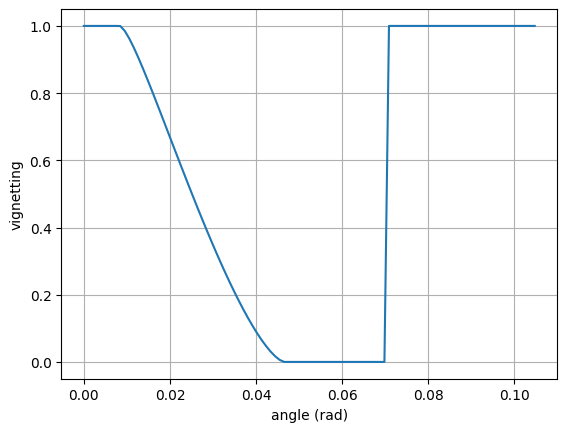

In [4]:
import matplotlib.pyplot as plt

plt.plot(r_arr, vig_arr)
plt.grid()
plt.xlabel('angle (rad)')
plt.ylabel('vignetting')

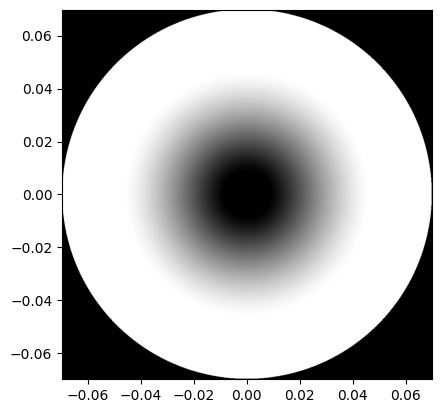

In [5]:
x = np.linspace(-theta_m, theta_m, 1000)
y = np.linspace(-theta_m, theta_m, 1000)

xx, yy = np.meshgrid(x, y, indexing='ij')
R = np.sqrt(xx**2 + yy**2)
X = cor.vignetting(R)

plt.imshow(X, extent=(-theta_m, theta_m, -theta_m, theta_m), cmap='binary')

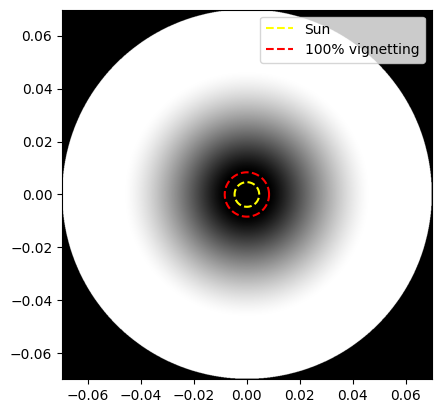

In [6]:
angles = np.linspace(0.0, 2*np.pi, 100)

plt.imshow(X, extent=(-theta_m, theta_m, -theta_m, theta_m), cmap='binary')
plt.plot(theta_sun * np.cos(angles), theta_sun * np.sin(angles), '--', color='yellow')
plt.plot(theta_v0 * np.cos(angles), theta_v0 * np.sin(angles), '--', color='red')
plt.legend(['Sun', '100% vignetting'])